In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Helper Function for Text Cleaning:

Implement a Helper Function as per Text Preprocessing Notebook and Complete the following pipeline.

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Build a Text Cleaning Pipeline

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def text_cleaning_pipeline(text, rule="lemmatize"):
    """
    Clean and preprocess a single text string.
    """

    data = text.lower()
    data = re.sub(r'http\S+|www\S+', '', data)

    # Remove emojis (basic pattern)
    data = re.sub(r'[^\w\s]', '', data)

    # Remove unwanted characters
    data = re.sub(r'[^a-zA-Z\s]', '', data)

    # Tokenization
    tokens = data.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization or Stemming
    if rule == "lemmatize":
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    elif rule == "stem":
        tokens = [stemmer.stem(word) for word in tokens]
    else:
        print("Pick between lemmatize or stem")

    return " ".join(tokens)

# Text Classification using Machine Learning Models


### 📝 Instructions: Trump Tweet Sentiment Classification

1. **Load the Dataset**  
   Load the dataset named `"trump_tweet_sentiment_analysis.csv"` using `pandas`. Ensure the dataset contains at least two columns: `"text"` and `"label"`.

2. **Text Cleaning and Tokenization**  
   Apply a text preprocessing pipeline to the `"text"` column. This should include:
   - Lowercasing the text  
   - Removing URLs, mentions, punctuation, and special characters  
   - Removing stopwords  
   - Tokenization (optional: stemming or lemmatization)
   - "Complete the above function"

3. **Train-Test Split**  
   Split the cleaned and tokenized dataset into **training** and **testing** sets using `train_test_split` from `sklearn.model_selection`.

4. **TF-IDF Vectorization**  
   Import and use the `TfidfVectorizer` from `sklearn.feature_extraction.text` to transform the training and testing texts into numerical feature vectors.

5. **Model Training and Evaluation**  
   Import **Logistic Regression** (or any machine learning model of your choice) from `sklearn.linear_model`. Train it on the TF-IDF-embedded training data, then evaluate it using the test set.  
   - Print the **classification report** using `classification_report` from `sklearn.metrics`.


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AI and ML/trum_tweet_sentiment_analysis.csv")

# Apply cleaning to the 'text' column
df['cleaned_text'] = df['text'].apply(text_cleaning_pipeline)
print(df[['text', 'cleaned_text', 'Sentiment']].head())

                                                text  \
0  RT @JohnLeguizamo: #trump not draining swamp b...   
1  ICYMI: Hackers Rig FM Radio Stations To Play A...   
2  Trump protests: LGBTQ rally in New York https:...   
3  "Hi I'm Piers Morgan. David Beckham is awful b...   
4  RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...   

                                        cleaned_text  Sentiment  
0  rt trump draining swamp taxpayer dollar trip a...          0  
1  icymi hacker rig fm radio station play antitru...          0  
2    trump protest lgbtq rally new york bbcworld via          1  
3  hi im pier morgan david beckham awful donald t...          0  
4  rt tech firm suing buzzfeed publishing unverif...          0  


In [ ]:
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96    248563
           1       0.93      0.91      0.92    121462

    accuracy                           0.95    370025
   macro avg       0.94      0.94      0.94    370025
weighted avg       0.95      0.95      0.95    370025



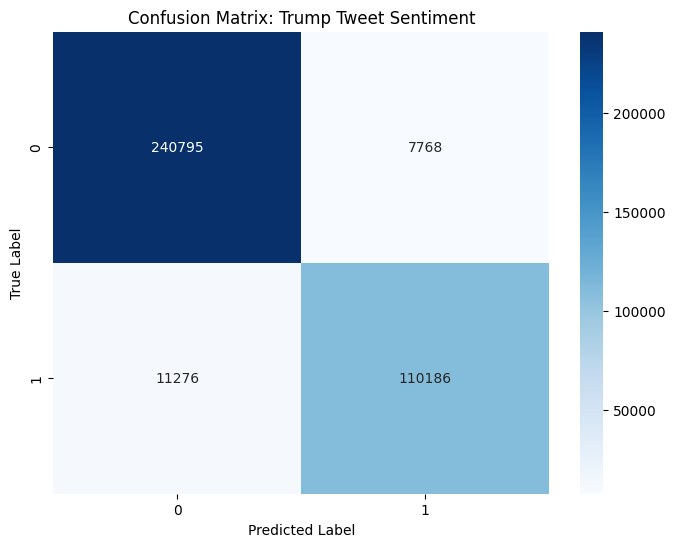

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix: Trump Tweet Sentiment')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()